In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid')
print(" Libraries loaded!")

 Libraries loaded!


In [4]:
df = pd.read_csv('data/Sample - Superstore.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])

print("Shape:", df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# Build customer summary table
customer_df = df.groupby('Customer Name').agg(
    Total_Sales    = ('Sales', 'sum'),
    Total_Profit   = ('Profit', 'sum'),
    Total_Orders   = ('Order ID', 'nunique'),
    Total_Quantity = ('Quantity', 'sum'),
    Avg_Discount   = ('Discount', 'mean')
).reset_index()

print("Total Customers:", len(customer_df))
print("\nSample Customer Profiles:")
customer_df.head(10)

Total Customers: 793

Sample Customer Profiles:


,Customer Name,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Avg_Discount
0,Aaron Bergman,886.156,129.3465,3,13,0.066667
1,Aaron Hawkins,1744.700,365.2152,7,54,0.090909
2,Aaron Smayling,3050.692,-253.5746,7,48,0.355000
3,Adam Bellavance,7755.620,2054.5885,8,56,0.044444
4,Adam Hart,3250.337,281.1890,10,75,0.135000
5,Adam Shillingsburg,3255.310,64.5374,9,81,0.180000
6,Adrian Barton,14473.571,5444.8055,10,73,0.240000
7,Adrian Hane,1735.514,-2.3146,7,65,0.237500
8,Adrian Shami,58.820,21.8496,2,9,0.066667
9,Aimee Bixby,966.710,313.6597,5,37,0.133333


In [9]:
# Select features for clustering
features = ['Total_Sales', 'Total_Profit', 'Total_Orders', 
            'Total_Quantity', 'Avg_Discount']

X = customer_df[features]

# Scale the data — very important for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled and ready!")
print("Shape:", X_scaled.shape)

Data scaled and ready!
Shape: (793, 5)


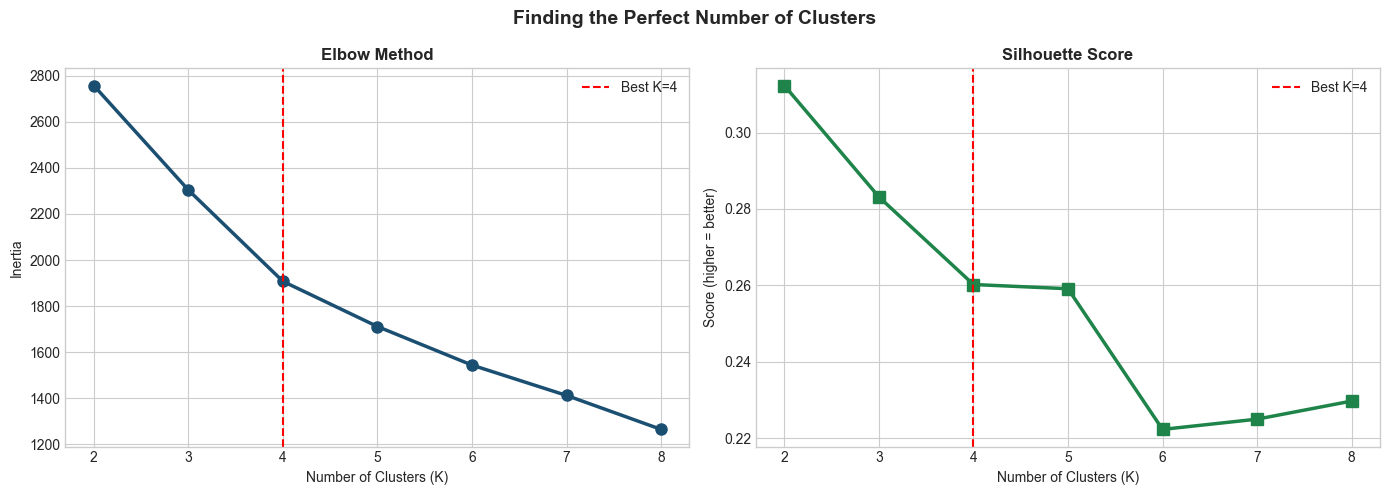

Best number of clusters = 4


In [8]:
# Elbow Method — finds the perfect number of clusters
inertia = []
silhouette = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finding the Perfect Number of Clusters', 
             fontsize=14, fontweight='bold')

axes[0].plot(K_range, inertia, marker='o', linewidth=2.5,
             color='#1B4F72', markersize=8)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', label='Best K=4')
axes[0].legend()

axes[1].plot(K_range, silhouette, marker='s', linewidth=2.5,
             color='#1E8449', markersize=8)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Score (higher = better)')
axes[1].axvline(x=4, color='red', linestyle='--', label='Best K=4')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart1_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Best number of clusters = 4")

In [10]:
# Apply K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Name the clusters based on behaviour
cluster_names = {
    0: 'Low Value',
    1: 'High Value', 
    2: 'At Risk',
    3: 'Loyal'
}

# See how many customers in each cluster
print("=== Customers per Cluster ===")
print(customer_df['Cluster'].value_counts().sort_index())

print("\n=== Average Profile per Cluster ===")
customer_df.groupby('Cluster')[features].mean().round(2)

=== Customers per Cluster ===
Cluster
0     58
1    191
2    264
3    280
Name: count, dtype: int64

=== Average Profile per Cluster ===


,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Avg_Discount
Cluster,,,,,
0,9379.48,2235.05,8.34,74.81,0.12
1,1590.51,-100.25,4.65,32.01,0.26
2,3648.77,339.61,8.64,68.68,0.16
3,1736.18,308.05,4.84,33.17,0.09


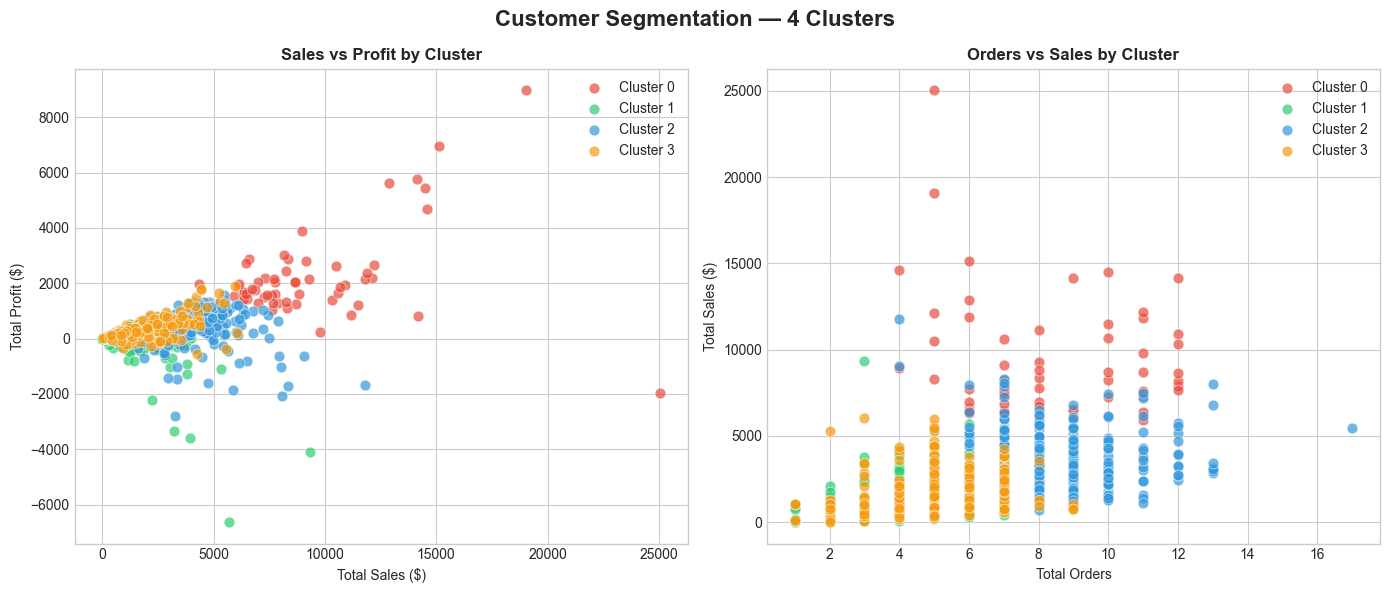

Cluster chart saved!


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Customer Segmentation — 4 Clusters', 
             fontsize=16, fontweight='bold')

colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12']
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

# Sales vs Profit scatter — coloured by cluster
for i in range(4):
    mask = customer_df['Cluster'] == i
    axes[0].scatter(
        customer_df[mask]['Total_Sales'],
        customer_df[mask]['Total_Profit'],
        c=colors[i], label=cluster_labels[i],
        alpha=0.7, s=60, edgecolors='white', linewidth=0.5
    )
axes[0].set_title('Sales vs Profit by Cluster', fontweight='bold')
axes[0].set_xlabel('Total Sales ($)')
axes[0].set_ylabel('Total Profit ($)')
axes[0].legend()

# Orders vs Sales scatter
for i in range(4):
    mask = customer_df['Cluster'] == i
    axes[1].scatter(
        customer_df[mask]['Total_Orders'],
        customer_df[mask]['Total_Sales'],
        c=colors[i], label=cluster_labels[i],
        alpha=0.7, s=60, edgecolors='white', linewidth=0.5
    )
axes[1].set_title('Orders vs Sales by Cluster', fontweight='bold')
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('Total Sales ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart2_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cluster chart saved!")

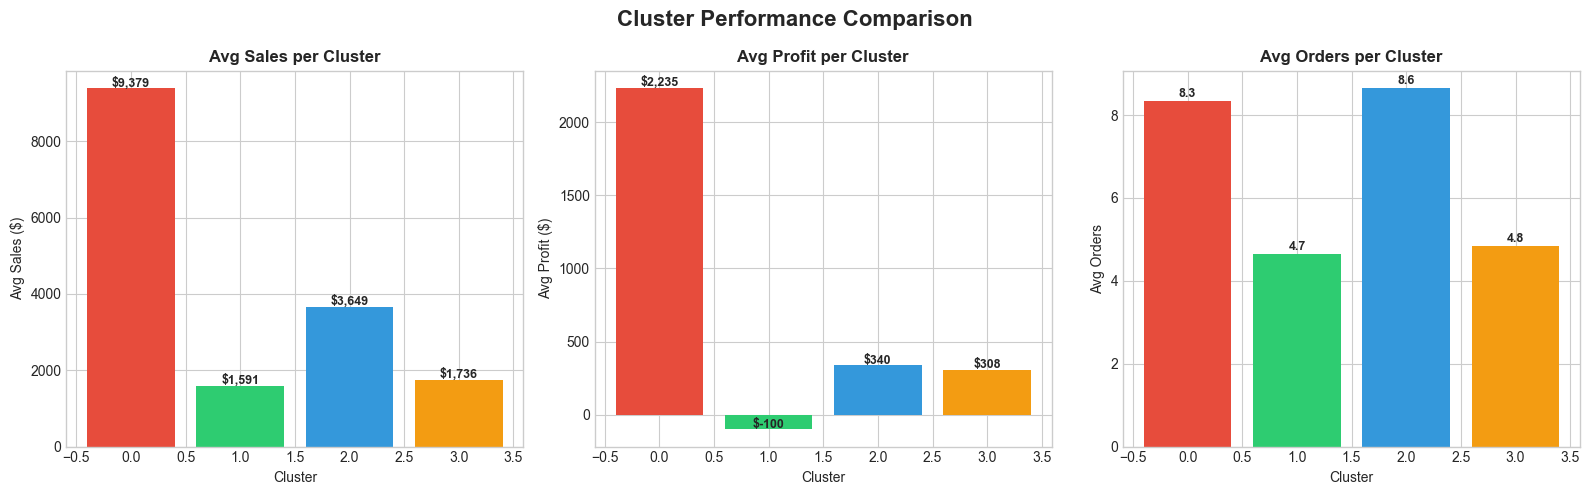

 Comparison chart saved!


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cluster Performance Comparison', fontsize=16, fontweight='bold')

cluster_summary = customer_df.groupby('Cluster')[features].mean().round(2)
colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12']

# Avg Sales per Cluster
axes[0].bar(cluster_summary.index, cluster_summary['Total_Sales'], color=colors)
axes[0].set_title('Avg Sales per Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Avg Sales ($)')
for i, val in enumerate(cluster_summary['Total_Sales']):
    axes[0].text(i, val + 50, f'${val:,.0f}', ha='center', 
                 fontsize=9, fontweight='bold')

# Avg Profit per Cluster
axes[1].bar(cluster_summary.index, cluster_summary['Total_Profit'], color=colors)
axes[1].set_title('Avg Profit per Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Avg Profit ($)')
for i, val in enumerate(cluster_summary['Total_Profit']):
    axes[1].text(i, val + 10, f'${val:,.0f}', ha='center', 
                 fontsize=9, fontweight='bold')

# Avg Orders per Cluster
axes[2].bar(cluster_summary.index, cluster_summary['Total_Orders'], color=colors)
axes[2].set_title('Avg Orders per Cluster', fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Avg Orders')
for i, val in enumerate(cluster_summary['Total_Orders']):
    axes[2].text(i, val + 0.1, f'{val:.1f}', ha='center', 
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_cluster_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Comparison chart saved!")

In [15]:
# Monthly sales for forecasting
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum().reset_index()

monthly_sales.columns = ['ds', 'y']
monthly_sales['ds'] = monthly_sales['ds'].dt.to_timestamp()

print("Monthly Sales Data:")
print(monthly_sales.head(10))
print(f"\nTotal months: {len(monthly_sales)}")

Monthly Sales Data:
          ds           y
0 2014-01-01  14236.8950
1 2014-02-01   4519.8920
2 2014-03-01  55691.0090
3 2014-04-01  28295.3450
4 2014-05-01  23648.2870
5 2014-06-01  34595.1276
6 2014-07-01  33946.3930
7 2014-08-01  27909.4685
8 2014-09-01  81777.3508
9 2014-10-01  31453.3930

Total months: 48


In [24]:
from prophet import Prophet

# Build and train the model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)
model.fit(monthly_sales)

# Forecast next 3 months
future = model.make_future_dataframe(periods=3, freq='MS')
forecast = model.predict(future)

print(" Forecast complete!")
print("\nNext 3 months prediction:")
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3).round(2)

10:04:48 - cmdstanpy - INFO - Chain [1] start processing
10:04:48 - cmdstanpy - INFO - Chain [1] done processing


 Forecast complete!

Next 3 months prediction:


,ds,yhat,yhat_lower,yhat_upper
48,2018-01-01,47286.50,38912.80,55754.25
49,2018-02-01,34616.64,26612.39,42932.26
50,2018-03-01,73956.70,64999.21,81717.96


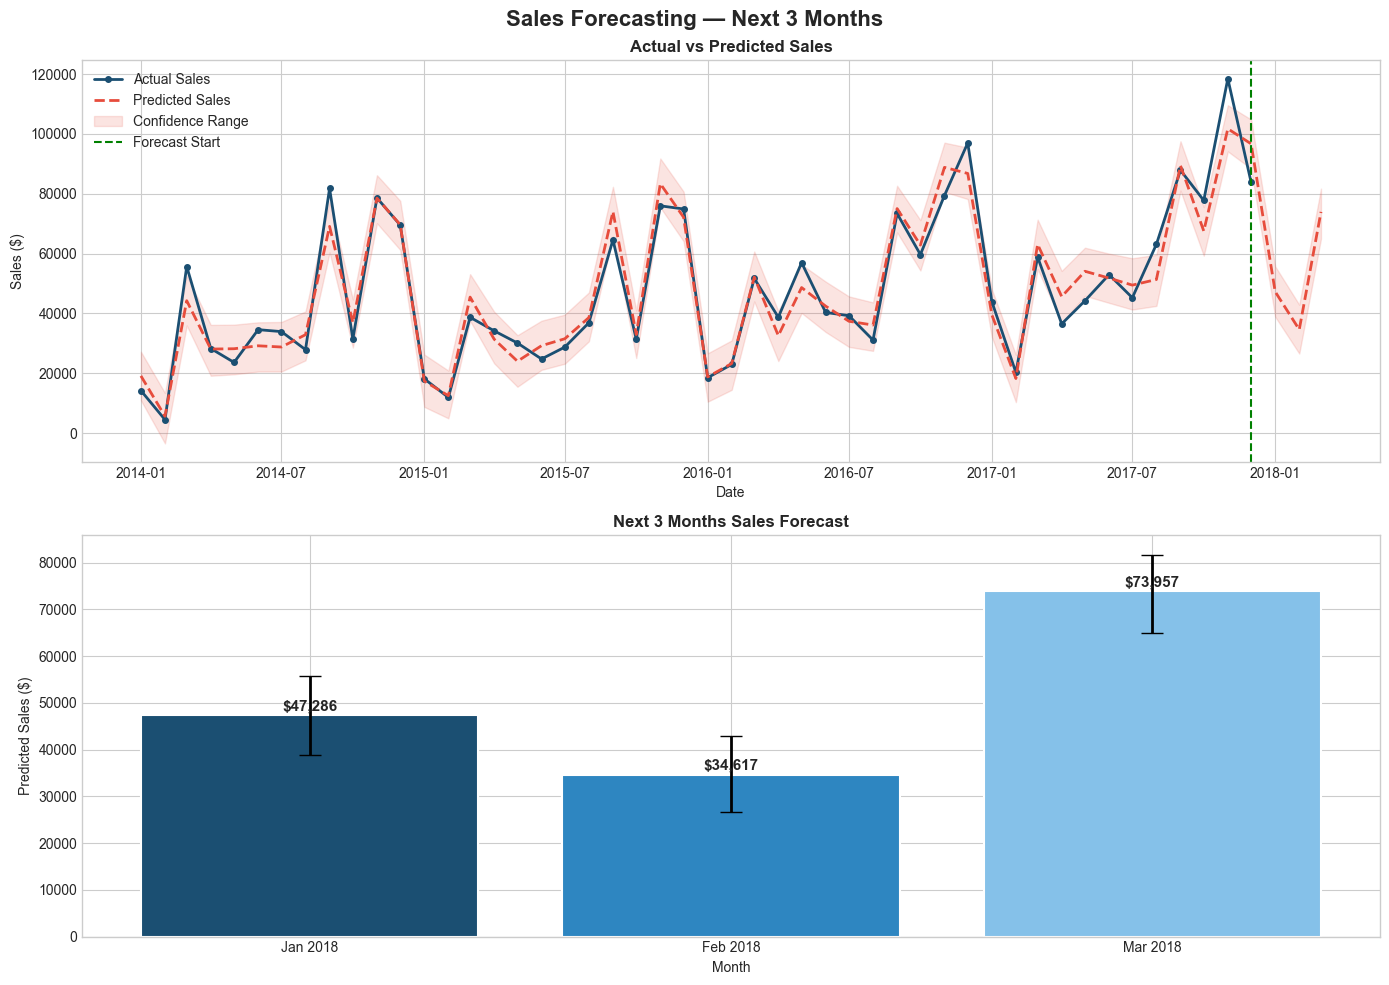

 Forecast chart saved!


In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Sales Forecasting — Next 3 Months', 
             fontsize=16, fontweight='bold')

# Plot 1 — Full forecast
axes[0].plot(monthly_sales['ds'], monthly_sales['y'], 
             color='#1B4F72', linewidth=2, label='Actual Sales', marker='o', markersize=4)
axes[0].plot(forecast['ds'], forecast['yhat'], 
             color='#E74C3C', linewidth=2, linestyle='--', label='Predicted Sales')
axes[0].fill_between(forecast['ds'], 
                      forecast['yhat_lower'], 
                      forecast['yhat_upper'],
                      alpha=0.15, color='#E74C3C', label='Confidence Range')

# Highlight forecast period
last_date = monthly_sales['ds'].max()
axes[0].axvline(x=last_date, color='green', linestyle='--', linewidth=1.5, label='Forecast Start')
axes[0].set_title('Actual vs Predicted Sales', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales ($)')
axes[0].legend()

# Plot 2 — Just the next 3 months
future_only = forecast[forecast['ds'] > last_date]
months = future_only['ds'].dt.strftime('%b %Y')
bars = axes[1].bar(months, future_only['yhat'], 
                    color=['#1B4F72', '#2E86C1', '#85C1E9'],
                    edgecolor='white', linewidth=1.5)
axes[1].errorbar(months, future_only['yhat'],
                  yerr=[future_only['yhat'] - future_only['yhat_lower'],
                        future_only['yhat_upper'] - future_only['yhat']],
                  fmt='none', color='black', capsize=8, linewidth=2)
for bar, val in zip(bars, future_only['yhat']):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 1000,
                 f'${val:,.0f}', ha='center', 
                 fontweight='bold', fontsize=11)
axes[1].set_title('Next 3 Months Sales Forecast', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Predicted Sales ($)')

plt.tight_layout()
plt.savefig('chart4_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Forecast chart saved!")

In [27]:
# Get forecast numbers
next3 = forecast[forecast['ds'] > last_date][['ds','yhat','yhat_lower','yhat_upper']]

print("=" * 55)
print("      CUSTOMER SEGMENTATION & FORECAST SUMMARY")
print("=" * 55)
print(f"\n Total Customers Analysed  : 793")
print(f"Clusters Identified       : 4")
print(f"\n VIP Customers (Cluster 0) : 58  — Avg Sales $9,379")
print(f"  At-Risk (Cluster 1)      : 191 — Avg Loss  -$100")
print(f" Mid-Tier (Cluster 2)      : 264 — Avg Sales $3,649")
print(f" Low Value (Cluster 3)     : 280 — Avg Sales $1,736")
print(f"\n 3-Month Sales Forecast:")
for _, row in next3.iterrows():
    print(f"   {row['ds'].strftime('%B %Y')}: ${row['yhat']:,.0f}  "
          f"(Range: ${row['yhat_lower']:,.0f} – ${row['yhat_upper']:,.0f})")
print("\n Key Insight: At-Risk customers using high discounts")
print("   (avg 26%) are generating negative profit — recommend")
print("   discount cap strategy for Cluster 1.")
print("=" * 55)
print("\n PROJECT 2 COMPLETE!")

      CUSTOMER SEGMENTATION & FORECAST SUMMARY

 Total Customers Analysed  : 793
Clusters Identified       : 4

 VIP Customers (Cluster 0) : 58  — Avg Sales $9,379
  At-Risk (Cluster 1)      : 191 — Avg Loss  -$100
 Mid-Tier (Cluster 2)      : 264 — Avg Sales $3,649
 Low Value (Cluster 3)     : 280 — Avg Sales $1,736

 3-Month Sales Forecast:
   January 2018: $47,286  (Range: $38,913 – $55,754)
   February 2018: $34,617  (Range: $26,612 – $42,932)
   March 2018: $73,957  (Range: $64,999 – $81,718)

 Key Insight: At-Risk customers using high discounts
   (avg 26%) are generating negative profit — recommend
   discount cap strategy for Cluster 1.

 PROJECT 2 COMPLETE!
